# 📚 Learning Notes - Hands-on Bioinformatics

In [1]:
import Bio


from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

In [2]:
# Note 1:
# To make a sequence, use Seq() on your seq
# Most properties of seq resemble those of a string, but some string methods/functions are not supported.
temp_seq = Seq('TGAACGCATGA')
temp_seq

Seq('TGAACGCATGA')

In [3]:
# Note 2:
# You can NOT call .remove() or replace a part;
# to do so, use Bio.Seq.MutableSeq()
mu_temp_seq = Bio.Seq.MutableSeq(temp_seq)
mu_temp_seq[1] = 'T'
mu_temp_seq.remove('G')
mu_temp_seq

MutableSeq('TTAACCATGA')

In [4]:
# Note 3:
# complement() and reverse_complement, transcribe(), trnaslate()
temp_dna_seq = Seq('ATGGCTTCACCGAATGGATAA')
temp_rna_seq = Seq('AUGGCUUCACCGAAUGGAUAA')

print(f'{Seq.complement(temp_dna_seq)}\n{Seq.transcribe(temp_rna_seq)}\n{Seq.translate(temp_rna_seq)}')

TACCGAAGTGGCTTACCTATT
AUGGCUUCACCGAAUGGAUAA
MASPNG*


In [5]:
# Note 4:
# to get Codon Table:
codon_table = Bio.Data.CodonTable.standard_dna_table
print(codon_table)

Table 1 Standard, SGC0

  |  T      |  C      |  A      |  G      |
--+---------+---------+---------+---------+--
T | TTT F   | TCT S   | TAT Y   | TGT C   | T
T | TTC F   | TCC S   | TAC Y   | TGC C   | C
T | TTA L   | TCA S   | TAA Stop| TGA Stop| A
T | TTG L(s)| TCG S   | TAG Stop| TGG W   | G
--+---------+---------+---------+---------+--
C | CTT L   | CCT P   | CAT H   | CGT R   | T
C | CTC L   | CCC P   | CAC H   | CGC R   | C
C | CTA L   | CCA P   | CAA Q   | CGA R   | A
C | CTG L(s)| CCG P   | CAG Q   | CGG R   | G
--+---------+---------+---------+---------+--
A | ATT I   | ACT T   | AAT N   | AGT S   | T
A | ATC I   | ACC T   | AAC N   | AGC S   | C
A | ATA I   | ACA T   | AAA K   | AGA R   | A
A | ATG M(s)| ACG T   | AAG K   | AGG R   | G
--+---------+---------+---------+---------+--
G | GTT V   | GCT A   | GAT D   | GGT G   | T
G | GTC V   | GCC A   | GAC D   | GGC G   | C
G | GTA V   | GCA A   | GAA E   | GGA G   | A
G | GTG V   | GCG A   | GAG E   | GGG G   | G
--+---------

In [6]:
# Note 5:
# To make a record -> SeqRecord()
# To write a record on your system as a file -> SeqIO.write()
# To read a record file from your system or here -> SeqIO.read()
temp_sr = SeqRecord(seq=Seq('ATGGCTTCACCGAATGGATAA'),
                        id='1',
                        description='Temp Seq')
SeqIO.write(temp_sr, '/mnt/d/Bioinformatics/Seq Records & Files/temp_seq.fasta', format='fasta')

1

In [7]:
print(SeqIO.read('/mnt/d/Bioinformatics/Seq Records & Files/10560.fasta', format='fasta'))

ID: NM_006996.3
Name: NM_006996.3
Description: NM_006996.3 Homo sapiens solute carrier family 19 member 2 (SLC19A2), transcript variant 1, mRNA
Number of features: 0
Seq('AGAGGCGTCTGTAGGGTAAAGCTGGGGGTTCTGTAGCCGGAGGCGGCGGCGAGT...AAA')


In [8]:
slc19a2 = SeqIO.read('/mnt/d/Bioinformatics/Seq Records & Files/10560.fasta', format='fasta')
slc19a2.seq[:20]

Seq('AGAGGCGTCTGTAGGGTAAA')

In [9]:
# To read a list of records -> SeqIO.parse()
temp_seq_list = [
    SeqIO.read('/mnt/d/Bioinformatics/Seq Records & Files/10560.fasta', format='fasta'),
    SeqIO.read('/mnt/d/Bioinformatics/Seq Records & Files/11532.fasta', format='fasta')
]
temp_seq_recs = SeqIO.write(temp_seq_list, '/mnt/d/Bioinformatics/Seq Records & Files/temp_seq_list.fasta', 'fasta')

for rec in SeqIO.parse('/mnt/d/Bioinformatics/Seq Records & Files/temp_seq_list.fasta', format='fasta'):
    print(f'{rec.id} information:\n{rec}\n')

NM_006996.3 information:
ID: NM_006996.3
Name: NM_006996.3
Description: NM_006996.3 Homo sapiens solute carrier family 19 member 2 (SLC19A2), transcript variant 1, mRNA
Number of features: 0
Seq('AGAGGCGTCTGTAGGGTAAAGCTGGGGGTTCTGTAGCCGGAGGCGGCGGCGAGT...AAA')

NM_004006.3 information:
ID: NM_004006.3
Name: NM_004006.3
Description: NM_004006.3 Homo sapiens dystrophin (DMD), transcript variant Dp427m, mRNA
Number of features: 0
Seq('ATCAGTTACTGTGTTGACTCACTCAGTGTTGGGATCACTCACTTTCCCCCTACA...AAA')



In [10]:
# Use next() to switch between records in a list of records
first_rec = next(SeqIO.parse('/mnt/d/Bioinformatics/Seq Records & Files/temp_seq_list.fasta', format='fasta'))
print(first_rec)

ID: NM_006996.3
Name: NM_006996.3
Description: NM_006996.3 Homo sapiens solute carrier family 19 member 2 (SLC19A2), transcript variant 1, mRNA
Number of features: 0
Seq('AGAGGCGTCTGTAGGGTAAAGCTGGGGGTTCTGTAGCCGGAGGCGGCGGCGAGT...AAA')


In [11]:
# to make a dictionary from your recs, use SeqIO.to_dict
SeqIO.to_dict(SeqIO.parse('/mnt/d/Bioinformatics/Seq Records & Files/temp_seq_list.fasta', format='fasta'))

{'NM_006996.3': SeqRecord(seq=Seq('AGAGGCGTCTGTAGGGTAAAGCTGGGGGTTCTGTAGCCGGAGGCGGCGGCGAGT...AAA'), id='NM_006996.3', name='NM_006996.3', description='NM_006996.3 Homo sapiens solute carrier family 19 member 2 (SLC19A2), transcript variant 1, mRNA', dbxrefs=[]),
 'NM_004006.3': SeqRecord(seq=Seq('ATCAGTTACTGTGTTGACTCACTCAGTGTTGGGATCACTCACTTTCCCCCTACA...AAA'), id='NM_004006.3', name='NM_004006.3', description='NM_004006.3 Homo sapiens dystrophin (DMD), transcript variant Dp427m, mRNA', dbxrefs=[])}

In [12]:
# Note that when calling functions such as complement in a loop for list of records, id, name and description may appear as UNKNOWN,
# to fix that, set them as function inputs
temp_recs = [rec.reverse_complement(id=rec.id) for rec in SeqIO.parse('/mnt/d/Bioinformatics/Seq Records & Files/temp_seq_list.fasta', format='fasta')]
    
temp_recs # Pay attention to the difference between id and name or description

[SeqRecord(seq=Seq('TTTTGATTAAAAAGAGAAAATATACTGTAAAATATTTATTTAATAAAAATAATT...TCT'), id='NM_006996.3', name='<unknown name>', description='<unknown description>', dbxrefs=[]),
 SeqRecord(seq=Seq('TTTTTTGTAACATAACTGCGTGCTTTATTGAGATACACAGTAAAGCAGTACTAT...GAT'), id='NM_004006.3', name='<unknown name>', description='<unknown description>', dbxrefs=[])]

In [13]:
# Note 6:
# For alignment, use Align.PairwiseAligner()
# Set mode (Global or Local) by using .mode()
# Get alignment score using .score()
from Bio import Align


seq_1 = 'AAACTACGGC'
seq_2 = 'AACCTAAGA'

aligner = Align.PairwiseAligner() # An alignment engine
# whose parameters (like mode) are configured first and then used to align the input sequences.
# Think of "aligner" as a configurable alignment machine, which:
#            PairwiseAligner
#                  │
#        ┌─────────┼──────────┐
#        ↓         ↓          ↓
#      mode      scoring    gap penalties
#        │         │          │
#     global    match       opening
#              mismatch    extension

aligner.mode = 'global'
aligner.match_score = 2
aligner.mismatch_score = -1
aligner.open_gap_score = 0.5
aligner.extend_gap_score = -0.1

alignments = aligner.align(seq_1, seq_2)

print(f'{alignments[0]}\nAlignment Score: {alignments.score}')

target            0 AA-ACTAC-GG-C 10
                  0 ||--|||---|-- 13
query             0 AAC-CTA-A-GA-  9

Alignment Score: 15.5


In [14]:
# we can use substitution matrices by loading and setting them to our aligner (aligner.substitution_matrices)
from Bio.Align import substitution_matrices


aligner.substitution_matrix = substitution_matrices.load('BLOSUM62')
aa_alignments = aligner.align('APID', 'APLDR')

for alignment in aa_alignments:
    print(f'{alignment}\n\n{alignment.score}')

target            0 APID- 4
                  0 ||.|- 5
query             0 APLDR 5


19.5


In [15]:
# Bio.pairwise2 was historically used for pairwise sequence alignment in Biopython. 
# It has been deprecated since Biopython 1.80, and Bio.Align.PairwiseAligner is the recommended modern alternative.

# globalms → global alignment with custom match/mismatch and gap scores
# globalxx → global alignment with simple match/mismatch scoring
# globalmc → global alignment with match/mismatch using function scoring
# pairwise2.align.* returns alignment results
# pairwise2 is mainly worth knowing for reading older code/tutorials.
# PairwiseAligner is the recommended modern API.

from Bio import pairwise2
from Bio.pairwise2 import format_alignment


alignments = pairwise2.align.globalms(
    "APID",
    "APLD",
    2,      # match score
    -1,     # mismatch score
    -0.5,   # gap opening penalty
    -0.1    # gap extension penalty
)

pairwise2.format_alignment(*alignments[0])

/home/mseifoori/miniconda3/envs/my_projects_env/lib/python3.13/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


'API-D\n||  |\nAP-LD\n  Score=5\n'

In [16]:
# Note 7 - Using motifs to make PSSM matrices:
from Bio import motifs


sequences = [
    "ATGCAA",
    "ATGCTA",
    "AAGCAA",
    "ATGCCA"
]

motif = motifs.create(sequences)

# motif.consensus, motif.counts, motif.pssm

print(motif.pssm)


        0      1      2      3      4      5
A:   2.00   0.00   -inf   -inf   1.00   2.00
C:   -inf   -inf   -inf   2.00   0.00   -inf
G:   -inf   -inf   2.00   -inf   -inf   -inf
T:   -inf   1.58   -inf   -inf   0.00   -inf



In [17]:
# the approach to make a PSSM matrix:
# motif (create) -> counts (normalize) -> PWM (log_odds) -> PSSM

sequences = [
    "ATGCAA",
    "ATGCTA",
    "AAGCAA",
    "ATGCCA"
]

motif = motifs.create(sequences)

pwm = motif.counts.normalize(pseudocounts=0.1) # to fix -inf values in PSSM (cause of log2(0))
pssm_1 = pwm.log_odds()

# you can also set background:
background = {
    "A": 0.30,
    "C": 0.20,
    "G": 0.20,
    "T": 0.30
}

pssm_2 = pwm.log_odds(background=background)

print(pssm_1, pssm_2)

        0      1      2      3      4      5
A:   1.90   0.00  -3.46  -3.46   0.93   1.90
C:  -3.46  -3.46  -3.46   1.90   0.00  -3.46
G:  -3.46  -3.46   1.90  -3.46  -3.46  -3.46
T:  -3.46   1.49  -3.46  -3.46   0.00  -3.46
         0      1      2      3      4      5
A:   1.64  -0.26  -3.72  -3.72   0.67   1.64
C:  -3.14  -3.14  -3.14   2.22   0.32  -3.14
G:  -3.14  -3.14   2.22  -3.14  -3.14  -3.14
T:  -3.72   1.23  -3.72  -3.72  -0.26  -3.72



In [19]:
# Note 8: Making a Phylogenetic Tree:

# 1. For phylogenetic tree construction, sequences are typically first subjected to Multiple Sequence Alignment (MSA).
# 2. We can use "Clustal Omega" to make alignments.
from Bio.Align import MultipleSeqAlignment


seqs = ['ATGCTA',
        'ATGCAA',
        'ATCCAA',
        'TTCCAA']

seq_records = []
for i, seq in enumerate(seqs, start=1):
    seq_records.append(SeqRecord(Seq(seq), id=f'seq_{i}'))

# Since Biopython does not verify whether the sequences are correctly aligned, 
# they should first undergo MSA using a tool such as Clustal Omega, 
# and the resulting alignment can then be loaded into Biopython for downstream analysis.
alignments = MultipleSeqAlignment(records=seq_records)

print(alignments)

Alignment with 4 rows and 6 columns
ATGCTA seq_1
ATGCAA seq_2
ATCCAA seq_3
TTCCAA seq_4


In [25]:
# "SeqIO" → reading/writing individual sequence records.
# "AlignIO" → reading/writing multiple sequence alignments.
# Note: Alignment information includes not only the sequences themselves, but also the positional relationships between their columns.
# and that's why we should use "AlignIO" instead of "SeqIO"
# Use AlignIO" when working with `MultipleSeqAlignment`.
from Bio import AlignIO


AlignIO.write(alignments,
              '/mnt/d/Bioinformatics/Seq Records & Files/alignments.phy',
              'phylip') # PHYLIP is a traditional and widely used standard format for phylogenetic data, supported by many phylogenetic analysis tools.

alignments = AlignIO.read('/mnt/d/Bioinformatics/Seq Records & Files/alignments.phy', 'phylip')
print(alignments.get_alignment_length())

6


In [29]:
# From Alignment to Distance:
# In distance-based phylogenetic methods, the aligned sequences are first used to estimate the evolutionary distance between each pair of sequences.
# (Distance Matrix)
# Use DistanceCalculator for this matter:
from Bio.Phylo.TreeConstruction import DistanceCalculator


d_calc = DistanceCalculator('identity') # Use identity for DNA seqs, BLOSUM or PAM for aa seqs

distance_matrix = d_calc.get_distance(alignments)

print(distance_matrix) # We can use pandas to have a better view over our matrices

seq_1   0.000000
seq_2   0.166667    0.000000
seq_3   0.333333    0.166667    0.000000
seq_4   0.500000    0.333333    0.166667    0.000000
    seq_1   seq_2   seq_3   seq_4


In [44]:
# Tree Construction:
# We have 2 ways:
#   Distance Matrix
#          ↓
#     ┌────┴─────┐
#     ↓          ↓
#    UPGMA       NJ
#     ↓          ↓
#    Tree      Tree
# UPGMA:
    # Unweighted Pair Group Method with Arithmetic Mean
    # At each step, identify the closest groups and merge them into a single cluster.
# NJ:
    # NJ progressively connects sequence/taxa that are identified as suitable neighbors based on their pairwise distances.
    # NJ is also a distance-based method; but unlike UPGMA, it does not assume a molecular clock.
    # In many real-world datasets, NJ is more flexible than UPGMA.

from Bio.Phylo.TreeConstruction import DistanceTreeConstructor


constructor = DistanceTreeConstructor()

upgma_tree = constructor.upgma(distance_matrix) # Approach n1

nj_tree = constructor.nj(distance_matrix) # Approach n2

In [45]:
print(upgma_tree)

Tree(rooted=True)
    Clade(branch_length=0, name='Inner3')
        Clade(branch_length=0.08333333333333337, name='Inner1')
            Clade(branch_length=0.08333333333333331, name='seq_4')
            Clade(branch_length=0.08333333333333331, name='seq_3')
        Clade(branch_length=0.08333333333333337, name='Inner2')
            Clade(branch_length=0.08333333333333331, name='seq_2')
            Clade(branch_length=0.08333333333333331, name='seq_1')


In [46]:
print(nj_tree)

Tree(rooted=False)
    Clade(branch_length=0, name='Inner2')
        Clade(branch_length=0.16666666666666666, name='seq_4')
        Clade(branch_length=-2.7755575615628914e-17, name='seq_3')
        Clade(branch_length=0.16666666666666669, name='Inner1')
            Clade(branch_length=0.16666666666666666, name='seq_1')
            Clade(branch_length=-2.7755575615628914e-17, name='seq_2')


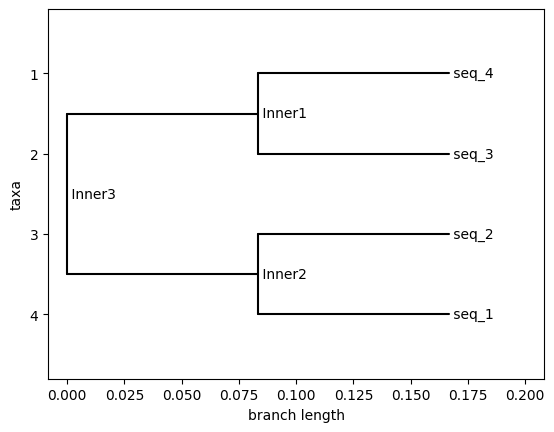

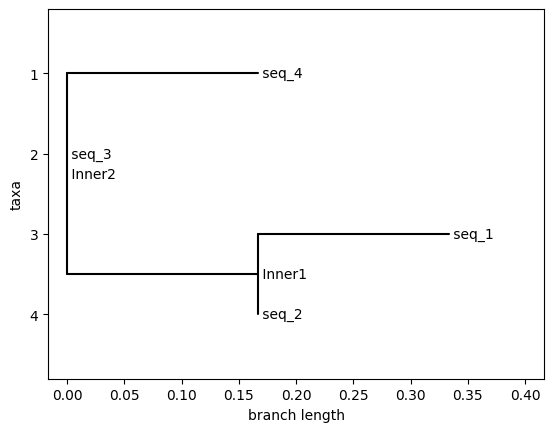

In [50]:
# Visualizing trees:
from Bio import Phylo


Phylo.draw(upgma_tree)
Phylo.draw(nj_tree)

In [52]:
# Toytree for phylogenetic trees:
#              ┌─ MSA
#              ↓
#         Phylogenetic
#           analysis
#              ↓
#            Tree
#              ↓
#        ┌─────┴─────┐
#        ↓           ↓
#    Bio.Phylo    toytree
#       ↓           ↓
#    basic           rich
#   handling     visualization

# A phylogenetic tree can be rooted or unrooted; NJ typically produces an unrooted tree.
# To infer the direction of evolutionary history, the tree generally needs to be rooted appropriately, for example, using an outgroup.

import toytree

temp_tree = toytree.tree('((A,B),(C,D));')

temp_tree.draw()

(<toyplot.canvas.Canvas at 0x70468f2b4b90>,
 <toytree.drawing.src.mark_toytree.ToyTreeMark at 0x70468f2b4cd0>)

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="275.0px" viewBox="0 0 300.0 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t1576258893254f4f87bfada1807f1032"> A B C D

In [55]:
# Note 9: Entrez, Swissprot, ExPASy, Prosite:

# Real workflow:
#                  Biological Question
#                         │
#             ┌───────────┴───────────┐
#             ↓                       ↓
#       NCBI / Entrez            UniProt / ExPASy
#             │                       │
#       search / fetch           protein information
#             │                       │
#       SeqRecord / XML          Swiss-Prot record
#             │                       │
#             └───────────┬───────────┘
#                         ↓
#                  Protein Sequence
#                         │
#                         ↓
#                      PROSITE
#                         │
#                 motifs / signatures
#                         │
#                         ↓
#                  Functional clues

# |         Resource         |                     What it is                          |                Primary use                |
# | ------------------------ | ------------------------------------------------------- | ----------------------------------------- |
# |   NCBI Entrez            | An access and search system for NCBI databases          |   Search & Retrieval                      |
# |   ExPASy                 | A bioinformatics resource portal by SIB                 |   Access to various tools and resources   |
# |   UniProt / Swiss-Prot   | A protein sequence and annotation database              |   Protein sequences & annotation          |
# |   PROSITE                | A database of protein signatures, domains, and patterns |   Functional pattern detection            |

In [61]:
# Entrez / NCBI:
# NCBI Entrez is an integrated system for searching and retrieving information from a collection of NCBI databases.

from Bio import Entrez

Entrez.email = 'sample@example.com'

# .esearch() -> search from a database
with Entrez.esearch(db='protein', term='P03018', retmax=10) as handle:
    rec = Entrez.read(handle) # The record is a Python dictionary-like data structure.
    
ids = rec['IdList']

# In fact, it's a more pythonic code for:
# handle = Entrez.esearch(db="protein", term="P03018")
# record = Entrez.read(handle)
# handle.close()

# Use retstart and retmax to implement simple pagination.

# .fetch() -> get a record from your search
with Entrez.efetch(db='protein', id=ids[0], rettype='fasta', retmode='text') as handle:
    fasta_text = handle.read()

In [65]:
#! Entrez -> esearch -> IdList -> efetch -> actual record -> SeqIO / Entrez.
# **TBC** !!!!!!!